In [64]:
import pandas as pd
df=pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/netflix_titles.csv")
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [65]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [66]:
df["date_added"]=pd.to_datetime(df["date_added"], format="mixed")

In [67]:
df["month_added"]=df["date_added"].dt.month
print(df.head(5))

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

In [68]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [69]:
df[["director","cast","country"]]=df[["director","cast","country"]].fillna("Unknown")


In [70]:
df=df.dropna()

In [71]:
print(df["country"].value_counts())

country
United States                                             2809
India                                                      972
Unknown                                                    829
United Kingdom                                             418
Japan                                                      243
                                                          ... 
Germany, Canada, United States                               1
Denmark, United Kingdom, South Africa, Sweden, Belgium       1
Serbia, South Korea, Slovenia                                1
United Kingdom, Spain, Belgium                               1
South Africa, United States, Japan                           1
Name: count, Length: 749, dtype: int64


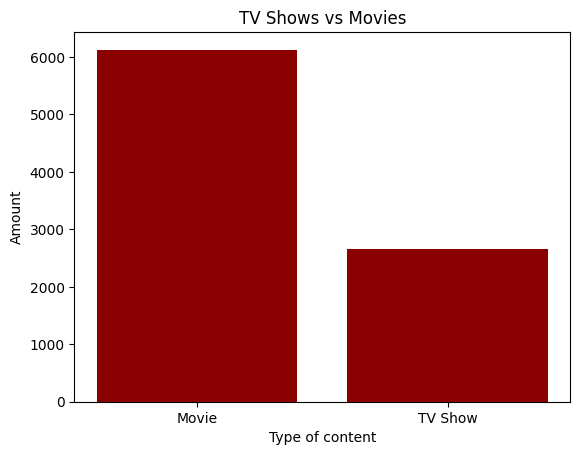

We can clearly see how the dominant thing on Netflix is movies


In [72]:
# ¿Qué tipo de contenido domina Netflix? — Películas vs Series
import matplotlib.pyplot as plt
vs_net=df["type"].value_counts()
plt.bar(vs_net.index,vs_net.values,color="darkred")
plt.title("TV Shows vs Movies")
plt.xlabel("Type of content")
plt.ylabel("Amount")
plt.show()

Movies represent over 60% of Netflix's total content catalog.

In [73]:
print(df["release_year"].agg(["min","max"]))
df["year_added"]=df['date_added'].dt.year

min    1925
max    2021
Name: release_year, dtype: int64


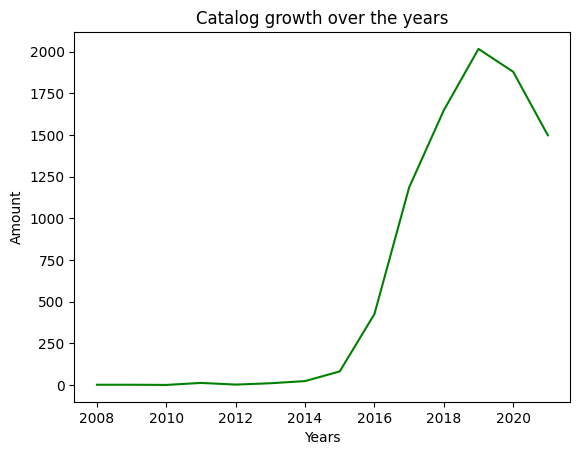

In [77]:
# ¿Cómo creció el catálogo a lo largo del tiempo? — evolución por año
growth=df['year_added'].value_counts().sort_index()
plt.plot(growth.index,growth.values, color="Green")
plt.title("Catalog growth over the years")
plt.xlabel("Years")
plt.ylabel("Amount")
plt.show()

It can be seen in the chart that the 2020 pandemic further accelerated the downward trend in content additions that had been building since approximately late 2018.

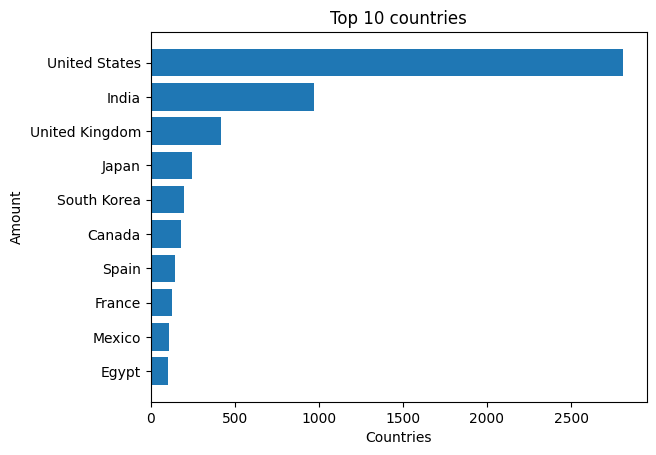

In [75]:
# ¿Qué países producen más contenido? — top 10 países
top_10=df[df["country"]!='Unknown']["country"].value_counts().head(10).sort_values(ascending=True)
plt.barh(top_10.index,top_10.values)
plt.title("Top 10 countries")
plt.xlabel("Countries")
plt.ylabel("Amount")
plt.show()

The country that produces the most content for Netflix is the USA, followed by India and the United Kingdom. Notably absent is China, the world's most populous country.

In [78]:
df.to_csv("Netflix_top_countries.csv")